strut length:  252.57106536095927
[660.   0.   0.]
name: center_node
 - displacement: [0. 0. 0.]
 - location: [0 0 0]
 - num: 0
name: strut_node
 - displacement: [  0.           0.         -14.71387143]
 - location: [660.   0.   0.]
 - num: 1
name: outer_node
 - displacement: [  0.           0.         -28.83058807]
 - location: [1000.    0.    0.]
 - num: 2
name: strut_node_top
 - displacement: [  0.           0.         -12.87495467]
 - location: [563.34523779 233.34523779   0.        ]
 - num: 3
name: strut_node_bottom
 - displacement: [  0.           0.         -12.87495467]
 - location: [ 563.34523779 -233.34523779    0.        ]
 - num: 4
[ 0.00000000e+00  0.00000000e+00 -1.47138714e+01 -1.23071925e-17
  3.80512397e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -2.88305881e+01 -8.82395732e-18  4.32374613e-02  0.00000000e+00
 -1.28749547e+01  0.00000000e+00  3.51547616e-02 -1.28749547e+01
  0.00000000e+00 -3.51547616e-02]
transverse shear constant arm: 0.5045639888135319
tra

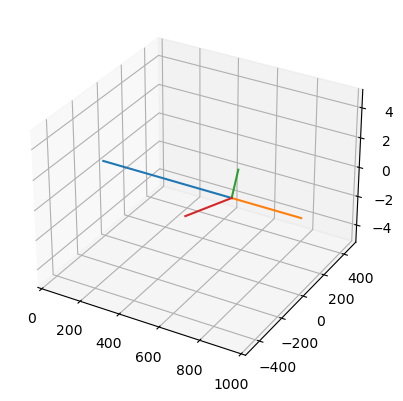

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone_geometry import DroneGeometry
from Scripts.drone_fea import DroneFEA
from Scripts.beams import BeamType
from Scripts.drone_battery import Battery
import Scripts.FEA_3D as FEA_3D

def plot_drone_geometry(drone):
    ax = plt.figure().add_subplot(projection='3d')
    ax.set_xlim([0, 1000])
    ax.set_ylim([-500, 500])
    ax.set_zlim([-5, 5])
    drone_geo = drone.beam_system
    node_loc = []
    for i in range(len(drone_geo.nodes)):
        node_loc.append(drone_geo.nodes[i].location)
    #ax.scatter(node_loc[:][0] + drone_geo.x_displacements,
    #           node_loc[:][1] + drone_geo.y_displacements, 
    #           node_loc[:][2] + drone_geo.z_displacements)
    
    for beam in drone_geo.beams:
        '''
        node_0_x = beam.start_node_coords[0]
        node_1_x = beam.end_node_coords[0]
        node_0_y = beam.start_node_coords[1]
        node_1_y = beam.end_node_coords[1]
        node_0_z = beam.start_node_coords[2]
        node_1_z = beam.end_node_coords[2]
        
        X_len = node_1_x - node_0_x
        Y_len = node_1_y - node_0_y
        Z_len = node_1_z - node_0_z

        X = np.empty(q)
        Y = np.empty(q)
        Z = np.empty(q)
        for i in range(q):
            N_X = FEA_3D.shape_function(X_len * i / q, X_len)
            N_Y = FEA_3D.shape_function(Y_len * i / q, Y_len)
            N_Z = FEA_3D.shape_function(Z_len * i / q, Z_len)
            X[i] = node_0_x + N_X[0] * beam.x_displacement[0] + N_X[1] * beam.x_angles[0] + N_X[2] * beam.x_displacement[1] + N_X[3] * beam.x_angles[1]
            Y[i] = node_0_y + N_Y[0] * beam.y_displacement[0] + N_Y[1] * beam.y_angles[0] +  N_Y[2] * beam.y_displacement[1] + N_Y[3] * beam.y_angles[1]
            Z[i] = node_0_z + N_Z[0] * beam.z_displacement[0] + N_Z[1] * beam.z_angles[0] + N_Z[2] * beam.z_displacement[1] + N_Z[3] * beam.z_angles[1]
        '''
        ax.plot([beam.start_node.location[0], beam.end_node.location[0]],
                [beam.start_node.location[1], beam.end_node.location[1]],
                [beam.start_node.location[2], beam.end_node.location[2]])


battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

arm_beam = BeamType("annulus", [29, 25], "Aluminum7075-T6", "arm_beam")
strut_beam = BeamType("annulus", [14, 12], "Aluminum7075-T6", "strut_beam")
d1 = DroneGeometry("drone_test", 1000, 660, 8, arm_beam, strut_beam, [battery_1, battery_2])
print("strut length: ", d1.strut_length/2)

d1_fea = DroneFEA(d1)

d1_fea.create_drone_slice_nodes()           # nominal radius | strut rad | number of blades
d1_fea.create_drone_slice_beams() # arm beam | strut beam
d1_fea.boundary_conditions_slice()
d1_fea.beam_system.add_force(np.array([0,0,-100]),"outer_node")
d1_fea.solve_fea()
plot_drone_geometry(d1_fea)

for node_num, node in enumerate(d1_fea.beam_system.nodes):
    print("name: " + str(d1_fea.beam_system.nodes[node_num].name))
    print(" - displacement: " + str(d1_fea.beam_system.nodes[node_num].result_displacement))
    print(" - location: " + str(d1_fea.beam_system.nodes[node_num].location))
    print(" - num: " + str(node_num))
    
print(d1_fea.beam_system.du)
print('transverse shear constant arm:', arm_beam.cross_section_properties['transverse shear deflection constant y'])
print('transverse shear constant strut:', strut_beam.cross_section_properties['transverse shear deflection constant y'])
# Abaqus results
# Strut node Z: -14.7435
# Outer node Z: -28.8806



In [3]:
# print("Shear Modulus:", 71700/(2 * (1+0.33)))

26954.88721804511
